# Regime-Aware Systematic Gas Trading Model  
Author: Mohit Kumar

---

## 1. Objective

This project builds a rule-based, regime-aware trading framework for Henry Hub natural gas futures.

The objective is to identify high-volatility environments combined with abnormal storage behavior and evaluate whether these regimes produce distinct forward return patterns.

The model does not forecast price levels directly.  
Instead, it classifies market regimes and evaluates conditional return behavior.

---

## 2. Data Used

The model uses two datasets:

### Henry Hub Daily Futures Prices
- Daily settlement prices
- Cleaned and converted to numeric format
- Sorted chronologically
- Indexed by date

### EIA Weekly Lower 48 Working Gas Storage
- Weekly storage levels
- Converted to numeric
- Indexed by date
- Used to construct weekly storage changes

All data is aligned at daily frequency. Weekly storage-derived variables are forward-filled to match daily price observations.

---

## 3. Storage Anomaly Construction

To remove seasonal effects, storage is transformed into a storage anomaly.

Step 1: Weekly Change  
weekly_change = Storage_t − Storage_{t-1}

Step 2: Seasonal Average  
For each ISO week-of-year, the historical average weekly change is calculated.

Step 3: Storage Anomaly  
storage_anomaly = weekly_change − seasonal_average

Interpretation:
- Negative anomaly → tighter-than-seasonal storage
- Positive anomaly → looser-than-seasonal storage

Only the anomaly is retained and merged with daily price data.

---

## 4. Feature Engineering

After merging daily prices with forward-filled storage anomaly:

### Log Returns
log_return = ln(P_t / P_{t-1})

Used for return aggregation and statistical stability.

---

### Rolling Volatility (20-day)
vol_20 = rolling standard deviation of log returns over 20 days

Serves as a stress proxy.

---

### 5-Day Forward Return (Evaluation Only)
fwd_5 = sum of next 5 daily log returns

Used to evaluate conditional performance of regimes.

---

### 5-Day Momentum
momentum_5 = rolling sum of past 5 daily log returns

This is computed but not used directly in regime classification.

---

## 5. Regime Definition

Regimes are defined using quantile thresholds:

- Volatility threshold = 75th percentile of vol_20
- Tight storage threshold = 25th percentile of storage_anomaly
- Loose storage threshold = 75th percentile of storage_anomaly

Regime classification:

1  → High volatility + tight storage (bullish stress)  
-1 → High volatility + loose storage (bearish stress)  
0  → Neutral conditions

---

## 6. Train / Test Split

The dataset is divided chronologically:

- Train: up to 31 December 2018  
- Test: 1 January 2019 onward  

This allows out-of-sample evaluation across structurally different market periods.

---

## 7. Trading Strategy Logic

Signal:
signal_t = regime_t

Execution:
strategy_return_t = signal_{t-1} × log_return_t

The one-day shift prevents lookahead bias by ensuring decisions are based only on information available at time t.

---

### Transaction Costs

A fixed transaction cost of 2 basis points (0.0002) is applied whenever the signal changes:

strategy_return_cost = strategy_return − |signal change| × transaction_cost

---

## 8. Performance Evaluation

For both Train and Test sets, the model computes:

- Cumulative strategy return
- Cumulative market return
- Annualized Sharpe ratio
- Maximum drawdown

---

## 9. Regime-Level Diagnostics

The model evaluates:

- Regime distribution
- Average 5-day forward returns by regime
- Yearly 5-day forward returns by regime

This helps assess regime stability across time.

---

## 10. Visualization

Cumulative returns for:

- Train Strategy
- Train Market
- Test Strategy
- Test Market

are plotted for comparison.

---

## 11. Model Scope

This implementation includes:

- Seasonal storage normalization
- Quantile-based regime classification
- Transaction cost adjustment
- Out-of-sample evaluation
- Drawdown analysis
- Regime-level diagnostics

This implementation does not include:

- Dynamic threshold estimation
- Position sizing or risk targeting
- Spread modeling
- Weather or export data
- Rolling parameter recalibration

Regime distribution:
regime
 0    3575
 1     299
-1     298
Name: count, dtype: int64
Train Sharpe: 0.3012183220399474
Test Sharpe: -0.1924532049145185
Train Max Drawdown: -0.29752099244011676
Test Max Drawdown: -0.7774950280064259

Yearly 5-Day Forward Returns by Regime:
year  regime
2010  -1        0.002069
       0       -0.006016
       1        0.091555
2011   0       -0.007985
2012  -1        0.019174
       0       -0.001797
       1        0.021789
2013   0        0.005492
2014  -1       -0.006250
       0       -0.007842
       1       -0.004586
2015  -1       -0.020389
       0       -0.001341
       1       -0.027317
2016  -1        0.046070
       0        0.006924
       1       -0.067943
2017   0       -0.002583
2018  -1       -0.147082
       0        0.004734
       1       -0.019029
2019  -1        0.035268
       0       -0.007885
       1       -0.001570
2020  -1       -0.093096
       0        0.004636
       1        0.068308
2021  -1       -0.019429
       0     

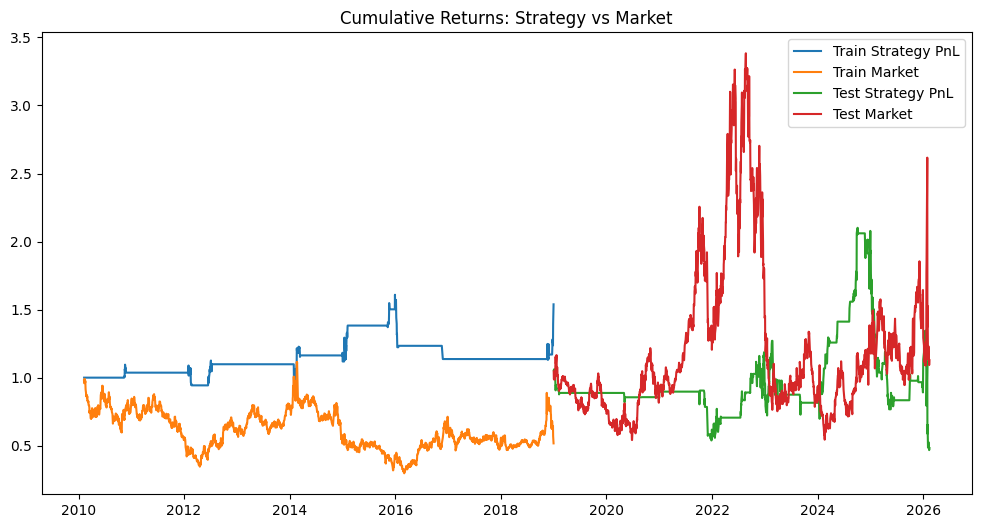

In [1]:
# =========================
# REGIME-AWARE SYSTEMATIC GAS TRADING MODEL
# Author: Mohit Kumar
# =========================

import pandas as pd
import numpy as np

# =========================
# 1. LOAD & CLEAN DATA
# =========================

# Henry Hub daily prices
hh = pd.read_csv("/content/drive/MyDrive/Regime-Aware Systematic Natural Gas Trading Model/Natural Gas Futures Historical Data.csv")
hh['Date'] = pd.to_datetime(hh['Date'], dayfirst=True)
hh = hh.sort_values('Date')
hh = hh[['Date', 'Price']]
hh['Price'] = hh['Price'].astype(str).str.replace(',', '')
hh['Price'] = pd.to_numeric(hh['Price'], errors='coerce')
hh = hh.dropna()
hh = hh.set_index('Date')

# EIA Storage weekly data
storage = pd.read_excel(
    "/content/drive/MyDrive/Regime-Aware Systematic Natural Gas Trading Model/NW2_EPG0_SWO_R48_BCFw.xls",
    sheet_name="Data 1",
    skiprows=2
)
storage.columns = ['Date', 'Storage']
storage['Date'] = pd.to_datetime(storage['Date'])
storage['Storage'] = pd.to_numeric(storage['Storage'], errors='coerce')
storage = storage.dropna()
storage = storage.sort_values('Date')
storage = storage.set_index('Date')

# =========================
# 2. BUILD STORAGE ANOMALY
# =========================

storage_weekly = storage.copy()
storage_weekly['weekly_change'] = storage_weekly['Storage'].diff()
storage_weekly['week'] = storage_weekly.index.isocalendar().week

# Seasonal average weekly change
seasonal_avg = storage_weekly.groupby('week')['weekly_change'].mean()
storage_weekly['seasonal_avg'] = storage_weekly['week'].map(seasonal_avg)

# Storage anomaly (surprise proxy)
storage_weekly['storage_anomaly'] = storage_weekly['weekly_change'] - storage_weekly['seasonal_avg']

# Keep anomaly only
anomaly = storage_weekly[['storage_anomaly']]

# =========================
# 3. MERGE DAILY DATA
# =========================

# Reindex anomaly to daily and forward-fill
anomaly_daily = anomaly.reindex(hh.index).ffill()
df = hh.join(anomaly_daily, how='left')
df = df.dropna()

# =========================
# 4. FEATURE ENGINEERING
# =========================

# Log returns
df['log_return'] = np.log(df['Price'] / df['Price'].shift(1))

# Rolling volatility (20-day)
df['vol_20'] = df['log_return'].rolling(20).std()

# 5-day forward return (for evaluation)
df['fwd_5'] = df['log_return'].rolling(5).sum().shift(-5)

# Price momentum (optional extra signal)
df['momentum_5'] = df['log_return'].rolling(5).sum()

df = df.dropna()

# =========================
# 5. REGIME DEFINITION
# =========================

# Volatility threshold (75th percentile)
vol_threshold = df['vol_20'].quantile(0.75)

# Storage anomaly thresholds (25th/75th percentile)
tight_threshold = df['storage_anomaly'].quantile(0.25)
loose_threshold = df['storage_anomaly'].quantile(0.75)

df['regime'] = 0

# Bullish stress regime
df.loc[
    (df['vol_20'] > vol_threshold) & (df['storage_anomaly'] < tight_threshold),
    'regime'
] = 1

# Bearish stress regime
df.loc[
    (df['vol_20'] > vol_threshold) & (df['storage_anomaly'] > loose_threshold),
    'regime'
] = -1

print("Regime distribution:")
print(df['regime'].value_counts())

# =========================
# 6. TRAIN/TEST SPLIT
# =========================

train = df.loc[:'2018-12-31'].copy()
test = df.loc['2019-01-01':].copy()

# =========================
# 7. STRATEGY BACKTEST (RISK-ADJUSTED)
# =========================

# Signal = regime
train['signal'] = train['regime']
test['signal'] = test['regime']

# Transaction cost per trade (2bps)
transaction_cost = 0.0002

for dataset in [train, test]:
    dataset['strategy_return'] = dataset['signal'].shift(1) * dataset['log_return']
    # Subtract transaction cost when signal changes
    dataset['strategy_return_cost'] = dataset['strategy_return'] - (dataset['signal'].diff().abs() * transaction_cost)
    dataset['cum_strategy'] = np.exp(dataset['strategy_return_cost'].cumsum())
    dataset['cum_market'] = np.exp(dataset['log_return'].cumsum())

# Compute Sharpe ratio (annualized)
for name, dataset in zip(['Train','Test'], [train, test]):
    sharpe = (dataset['strategy_return_cost'].mean() / dataset['strategy_return_cost'].std()) * np.sqrt(252)
    print(f"{name} Sharpe:", sharpe)

# Max Drawdown
for name, dataset in zip(['Train','Test'], [train, test]):
    roll_max = dataset['cum_strategy'].cummax()
    drawdown = dataset['cum_strategy'] / roll_max - 1
    print(f"{name} Max Drawdown:", drawdown.min())

# =========================
# 8. YEARLY & REGIME-LEVEL INSIGHTS
# =========================

df['year'] = df.index.year

yearly_fwd5 = df.groupby(['year','regime'])['fwd_5'].mean()
print("\nYearly 5-Day Forward Returns by Regime:")
print(yearly_fwd5)

# =========================
# 9. OPTIONAL VISUALIZATION (if using Jupyter)
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train['cum_strategy'], label='Train Strategy PnL')
plt.plot(train['cum_market'], label='Train Market')
plt.plot(test['cum_strategy'], label='Test Strategy PnL')
plt.plot(test['cum_market'], label='Test Market')
plt.title('Cumulative Returns: Strategy vs Market')
plt.legend()
plt.show()